Listo ✓
(1096, 10)


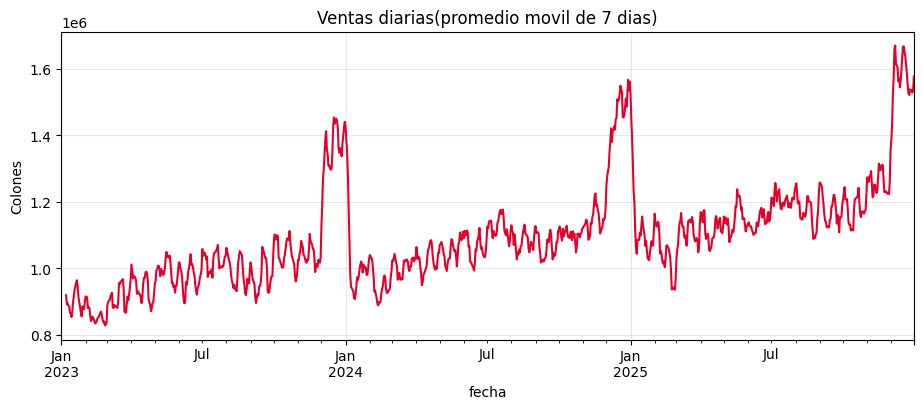

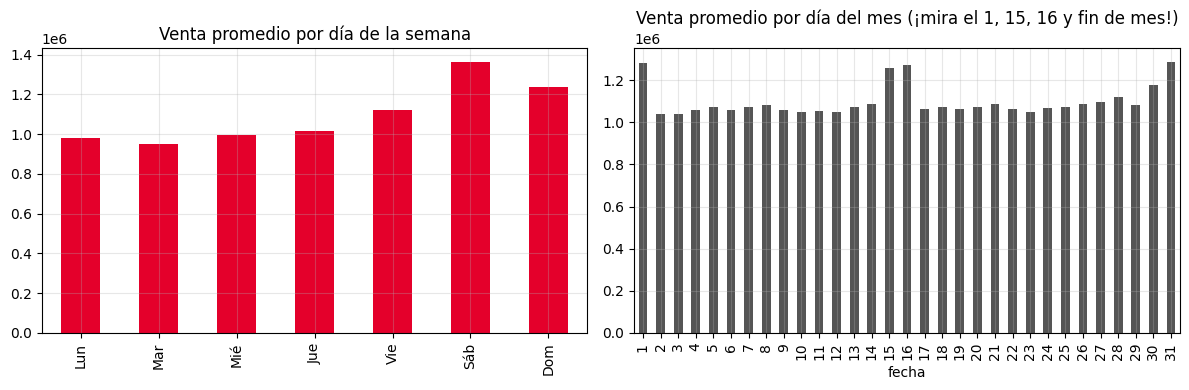

Entrenamiento : {len(X_train)} dias / Prueba : {len(X_test)} dias


In [ ]:
#Caso 1 Predicion de Ventas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")
print("Listo ✓")

#Paso 1 Crear los datos del supermercado.
rng = np.random.default_rng(42)
fechas = pd.date_range("2023-01-01", "2025-12-31", freq="D")
n=len(fechas)

dia_semana=fechas.dayofweek                                                    # 0 = lunes, 6=domingo
mes=fechas.month
dia=fechas.day
fin_de_mes=fechas.is_month_end

efecto_dia = np.array([0.90, 0.88, 0.92, 0.95, 1.05, 1.25, 1.15])[dia_semana]
efecto_mes = np.array([0.95, 0.88, 0.95, 0.97, 1.00, 0.98, 1.02, 0.98, 0.96, 0.99, 1.03, 1.30])[mes - 1]
quincena = ((dia == 15) | (dia == 16) | fin_de_mes | (dia == 1)).astype(int)
promo = (rng.random(n) < 0.12).astype(int)                                     # ~12 % de los días hay promo

tendencia=np.arange(n)
base=900_000+250*tendencia
ventas=base*efecto_dia*efecto_mes*(1+0.18*quincena)*(1+0.15*promo)
ventas=ventas*rng.normal(1,0.05,n)

df=pd.DataFrame({
    "fecha":fechas,
    "dia_semana":dia_semana,
    "mes":mes,
    "dia":dia,
    "fin_de_mes":fin_de_mes,
    "efecto_dia":efecto_dia,
    "efecto_mes":efecto_mes,
    "quincena":quincena,
    "promo":promo,
    "ventas":ventas.round(-2)
})

print(df.shape)
df.head(10)

ax=df.set_index("fecha")["ventas"].rolling(7).mean().plot(color="#E4002B",lw=1.5)
ax.set_title("Ventas diarias(promedio movil de 7 dias)")
ax.set_ylabel("Colones")
plt.show()

#-------------------------------------------------------------------------------------
nombres = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby(df["fecha"].dt.dayofweek)["ventas"].mean().set_axis(nombres).plot.bar(ax=axes[0], color="#E4002B")
axes[0].set_title("Venta promedio por día de la semana")

df.groupby(df["fecha"].dt.day)["ventas"].mean().plot.bar(ax=axes[1], color="#555555")
axes[1].set_title("Venta promedio por día del mes (¡mira el 1, 15, 16 y fin de mes!)")
plt.tight_layout(); plt.show()

#Paso 3 Convertir la fecha en pistas
def crear_pistas(tabla, fecha_inicio="2023-01-01"):
    t = pd.DataFrame(index=tabla.index)
    f = tabla["fecha"]
    t["tendencia"] = (f - pd.Timestamp(fecha_inicio)).dt.days
    t["quincena"] = (f.dt.day.isin([1, 15, 16]) | f.dt.is_month_end).astype(int)
    t["promo"] = tabla["promo"]
    t = t.join(pd.get_dummies(f.dt.dayofweek, prefix="dia").astype(int))
    t = t.join(pd.get_dummies(f.dt.month, prefix="mes").astype(int))
    return t

X = crear_pistas(df)
y = df["ventas"]
X.head()

#Paso 4 separar respetando el tiempo
corte=df["fecha"]<"2025-10-1"
X_train, X_test = X[corte], X[~corte]
y_train, y_test = y[corte], y[~corte]

print("Entrenamiento : {len(X_train)} dias / Prueba : {len(X_test)} dias")

#paso 5 la linea base
#Paso 5 La linea base
pred_base = df["ventas"].shift(7)[~corte]                                      #misma venta de hace 7 dias


Listo ✔
(1641, 6)


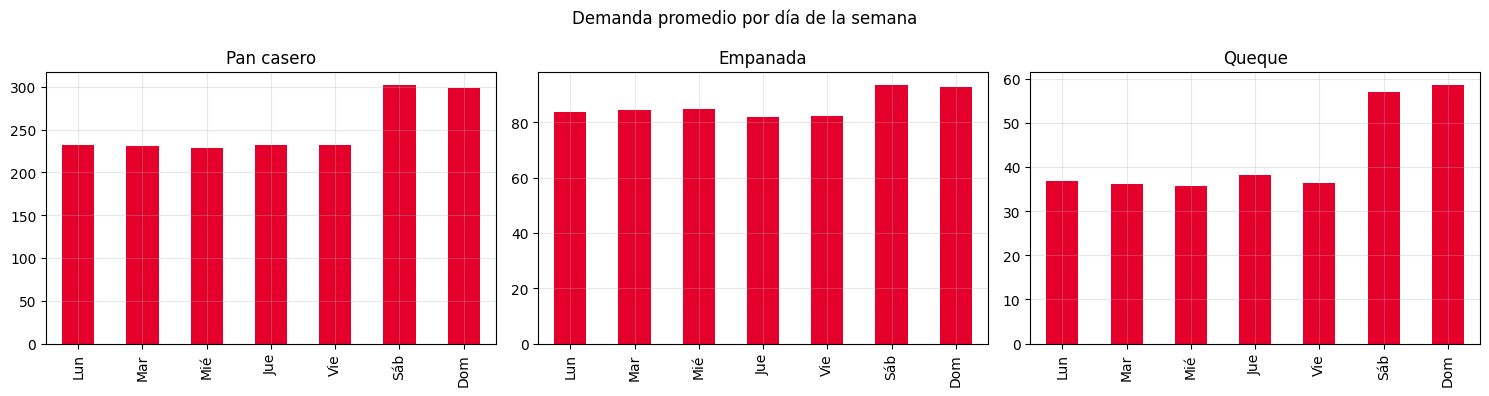

Filas entrenamiento: 1458 | Filas prueba: 183
regla_actual  → se equivoca en promedio por 18.2 unidades por producto por día
prediccion    → se equivoca en promedio por 8.9 unidades por producto por día


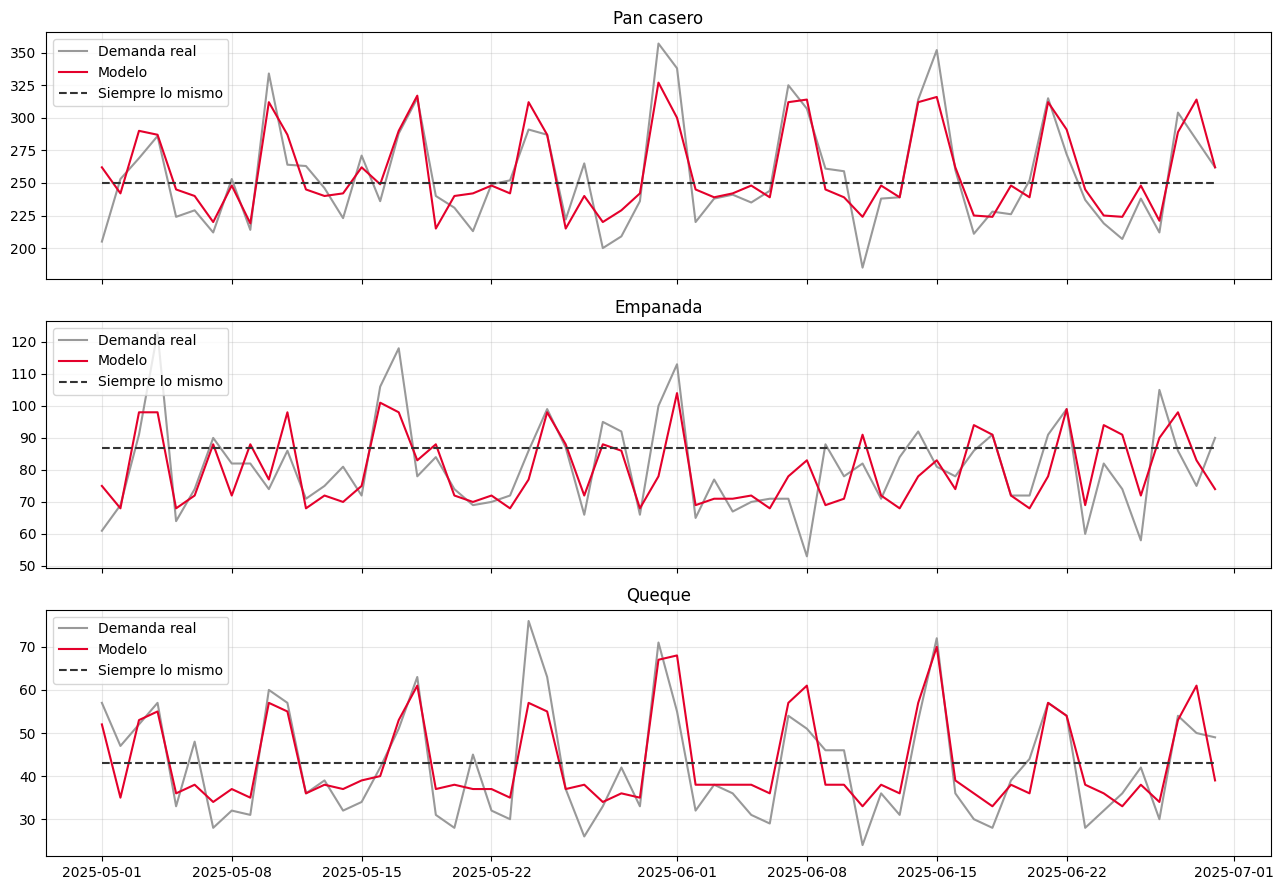

Pérdida con 'siempre lo mismo': ₡813,380 en 61 días
Pérdida con el modelo:          ₡416,140 en 61 días
Ahorro: ₡397,240  →  aprox. ₡2,376,928 al año
Mejor colchón: 3%


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
print("Listo ✔")
rng = np.random.default_rng(7)
fechas = pd.date_range("2024-01-01", "2025-06-30", freq="D")
feriados = pd.to_datetime([
    "2024-01-01", "2024-03-28", "2024-03-29", "2024-04-11", "2024-05-01", "2024-07-25",
    "2024-08-02", "2024-08-15", "2024-09-15", "2024-12-01", "2024-12-25",
    "2025-01-01", "2025-04-11", "2025-04-17", "2025-04-18", "2025-05-01",
])
productos = {
    #            base   efecto fin de semana  efecto lluvia
    "Pan casero": (220,  1.30,                 1.10),   # con lluvia la gente compra pan para el cafecito
    "Empanada":   (90,   1.10,                 0.80),
    "Queque":     (35,   1.60,                 1.05),
}
filas = []
lluvia_dia = {}
for f in fechas:
    temporada_lluviosa = 5 <= f.month <= 11
    lluvia_dia[f] = int(rng.random() < (0.65 if temporada_lluviosa else 0.15))
for f in fechas:
    for prod, (base, fin_sem, ef_lluvia) in productos.items():
        lluvia = lluvia_dia[f]
        es_finde = f.dayofweek >= 5
        es_feriado = int(f in feriados)
        quincena = int(f.day in (1, 15, 16) or f.is_month_end)
        media = base
        media *= fin_sem if es_finde else 1
        media *= ef_lluvia if lluvia else 1
        media *= 1.35 if (es_feriado and prod == "Queque") else (0.85 if es_feriado else 1)
        media *= 1.12 if quincena else 1
        demanda = rng.poisson(media)
        filas.append([f, prod, lluvia, es_feriado, quincena, demanda])

df = pd.DataFrame(filas, columns=["fecha", "producto", "lluvia", "feriado", "quincena", "demanda"])
print(df.shape)
df.head(9)

df["dia_semana"] = df["fecha"].dt.dayofweek
nombres = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, prod in zip(axes, productos):
    d = df[df["producto"] == prod]
    d.groupby("dia_semana")["demanda"].mean().set_axis(nombres).plot.bar(ax=ax, color="#E4002B")
    ax.set_title(prod)
plt.suptitle("Demanda promedio por día de la semana"); plt.tight_layout(); plt.show()
tabla_lluvia = df.pivot_table(index="producto", columns="lluvia", values="demanda", aggfunc="mean").round(0)
tabla_lluvia.columns = ["Sin lluvia", "Con lluvia"]
tabla_lluvia["Cambio %"] = ((tabla_lluvia["Con lluvia"] / tabla_lluvia["Sin lluvia"] - 1) * 100).round(0)
tabla_lluvia
def preparar(tabla):
    X = tabla[["lluvia", "feriado", "quincena"]].copy()
    X["mes"] = tabla["fecha"].dt.month
    X = X.join(pd.get_dummies(tabla["fecha"].dt.dayofweek, prefix="dia").astype(int))
    X = X.join(pd.get_dummies(tabla["producto"], prefix="prod").astype(int))
    return X

X = preparar(df)
y = df["demanda"]

corte = df["fecha"] < "2025-05-01"            # prueba: mayo y junio 2025
X_train, X_test, y_train, y_test = X[corte], X[~corte], y[corte], y[~corte]
print(f"Filas entrenamiento: {len(X_train)} | Filas prueba: {len(X_test)}")
X.head()
modelo = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42)
modelo.fit(X_train, y_train)

prueba = df[~corte].copy()
prueba["prediccion"] = modelo.predict(X_test).round()

promedio_hist = df[corte].groupby("producto")["demanda"].mean().round()
prueba["regla_actual"] = prueba["producto"].map(promedio_hist)     # "siempre lo mismo"

for nombre in ["regla_actual", "prediccion"]:
    mae = mean_absolute_error(prueba["demanda"], prueba[nombre])
    print(f"{nombre:13s} → se equivoca en promedio por {mae:.1f} unidades por producto por día")
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, prod in zip(axes, productos):
    d = prueba[prueba["producto"] == prod]
    ax.plot(d["fecha"], d["demanda"], color="#999999", label="Demanda real")
    ax.plot(d["fecha"], d["prediccion"], color="#E4002B", label="Modelo")
    ax.plot(d["fecha"], d["regla_actual"], color="#333333", ls="--", label="Siempre lo mismo")
    ax.set_title(prod); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()
costo    = {"Pan casero": 80, "Empanada": 200, "Queque": 250}
ganancia = {"Pan casero": 220, "Empanada": 500, "Queque": 650}

def perdida(tabla, columna_plan):
    sobra = (tabla[columna_plan] - tabla["demanda"]).clip(lower=0)
    falta = (tabla["demanda"] - tabla[columna_plan]).clip(lower=0)
    return (sobra * tabla["producto"].map(costo) + falta * tabla["producto"].map(ganancia)).sum()

p_actual = perdida(prueba, "regla_actual")
p_modelo = perdida(prueba, "prediccion")
dias = prueba["fecha"].nunique()
print(f"Pérdida con 'siempre lo mismo': ₡{p_actual:,.0f} en {dias} días")
print(f"Pérdida con el modelo:          ₡{p_modelo:,.0f} en {dias} días")
print(f"Ahorro: ₡{p_actual - p_modelo:,.0f}  →  aprox. ₡{(p_actual - p_modelo) / dias * 365:,.0f} al año")
resultados = []
for extra in [0, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20]:
    prueba["plan"] = np.ceil(prueba["prediccion"] * (1 + extra))
    resultados.append({"colchón": extra, "pérdida ₡": perdida(prueba, "plan")})
res = pd.DataFrame(resultados)
mejor_colchon = res.loc[res["pérdida ₡"].idxmin(), "colchón"]
print(f"Mejor colchón: {mejor_colchon:.0%}")
res.style.format({"colchón": "{:.0%}", "pérdida ₡": "₡{:,.0f}"}).highlight_min(subset="pérdida ₡", color="#E4002B55")
modelo_final = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42).fit(X, y)

manana = pd.DataFrame({
    "fecha": pd.Timestamp("2025-07-05"),
    "producto": list(productos),
    "lluvia": 1, "feriado": 0, "quincena": 0,
})
X_manana = preparar(manana).reindex(columns=X.columns, fill_value=0)
colchon = mejor_colchon          # el que ganó en el Paso 6
manana["pronostico"] = modelo_final.predict(X_manana).round()
manana["hornear"] = np.ceil(manana["pronostico"] * (1 + colchon)).astype(int)
manana[["producto", "pronostico", "hornear"]]